# Health Market Volatility — Two-Stage Predictive Pipeline

This notebook builds a two-stage predictive pipeline: ARIMA is used to model baseline weekly volatility in the XLV (Health Care Select Sector) ETF, then a Random Forest is trained on the ARIMA residuals using lagged public health signals as features. The goal is to determine whether publicly observable health indicators can explain volatility shocks that a pure time-series model cannot account for.

## Dependencies & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

master_df = pd.read_csv('../data/processed/master_weekly.csv', index_col=0, parse_dates=True)
print(master_df.shape)
print(master_df.head())

(730, 19)
                 KIE        PJP        XBI        XLV   KIE_vol   PJP_vol  \
2010-01-10  9.057225  15.203443  17.865004  24.007961  0.008310  0.003637   
2010-01-17  9.049768  15.413590  17.691778  24.340349  0.009688  0.010255   
2010-01-24  8.721590  15.033717  17.666115  23.917307  0.018964  0.019509   
2010-01-31  8.768827  15.049875  17.733477  23.630234  0.011464  0.007055   
2010-02-07  8.656946  14.823567  17.617998  23.290281  0.022845  0.017174   

             XBI_vol   XLV_vol      cpi  unemployment  interest_rate  \
2010-01-10  0.005600  0.008326  217.488           9.8           0.11   
2010-01-17  0.013182  0.009302  217.488           9.8           0.11   
2010-01-24  0.016421  0.019749  217.488           9.8           0.11   
2010-01-31  0.010720  0.005938  217.488           9.8           0.11   
2010-02-07  0.027868  0.017661  217.281           9.8           0.13   

            trends_flu_symptoms  trends_fever  trends_shortness_of_breath  \
2010-01-10       

The master dataset contains 730 weekly observations across 19 columns spanning January 2010 through December 2023. Columns include ETF prices and realized volatility, macroeconomic indicators (CPI, unemployment, interest rate), Google Trends search volumes for health-related queries, and CDC influenza surveillance metrics (ILI, WILI, patient counts).

## Stage 1 — ARIMA Model

### Stationarity Check (ADF Test)

In [2]:
from statsmodels.tsa.stattools import adfuller

split_idx = int(len(master_df) * 0.8)
train_vol = master_df['XLV_vol'].iloc[:split_idx]
test_vol = master_df['XLV_vol'].iloc[split_idx:]
result_adf = adfuller(train_vol)


print(f"ADF Statistic: {result_adf[0]:.4f}")
print(f"p-value: {result_adf[1]:.4f}")
# Null hypothesis is that the series has a unit root (non-stationary); p < 0.05 rejects it
print("Stationary" if result_adf[1] < 0.05 else "NOT stationary")

ADF Statistic: -9.1507
p-value: 0.0000
Stationary


The ADF test strongly rejects the null hypothesis of a unit root (p ≈ 0.00), confirming that weekly XLV volatility is stationary. This means ARIMA does not require differencing (d = 0) and can model the series in levels.

### Model Fitting & Summary

In [3]:
# --- AIC/BIC comparison across candidate orders ---
import itertools
import warnings
warnings.filterwarnings('ignore')



candidate_orders = [(0,0,1), (1,0,0), (1,0,1), (2,0,0), (2,0,1), (1,0,2), (2,0,2)]

results = []
for order in candidate_orders:
    try:
        m = ARIMA(train_vol, order=order).fit()
        results.append({
            'order': order,
            'AIC': m.aic,
            'BIC': m.bic
        })
    except Exception as e:
        results.append({'order': order, 'AIC': None, 'BIC': None})

aic_bic_df = pd.DataFrame(results).sort_values('AIC')
print(aic_bic_df)

       order          AIC          BIC
3  (2, 0, 0) -4524.726086 -4507.246482
2  (1, 0, 1) -4523.411838 -4505.932234
4  (2, 0, 1) -4522.881907 -4501.032402
5  (1, 0, 2) -4522.102746 -4500.253241
6  (2, 0, 2) -4521.610160 -4495.390754
1  (1, 0, 0) -4510.053209 -4496.943506
0  (0, 0, 1) -4405.781129 -4392.671426


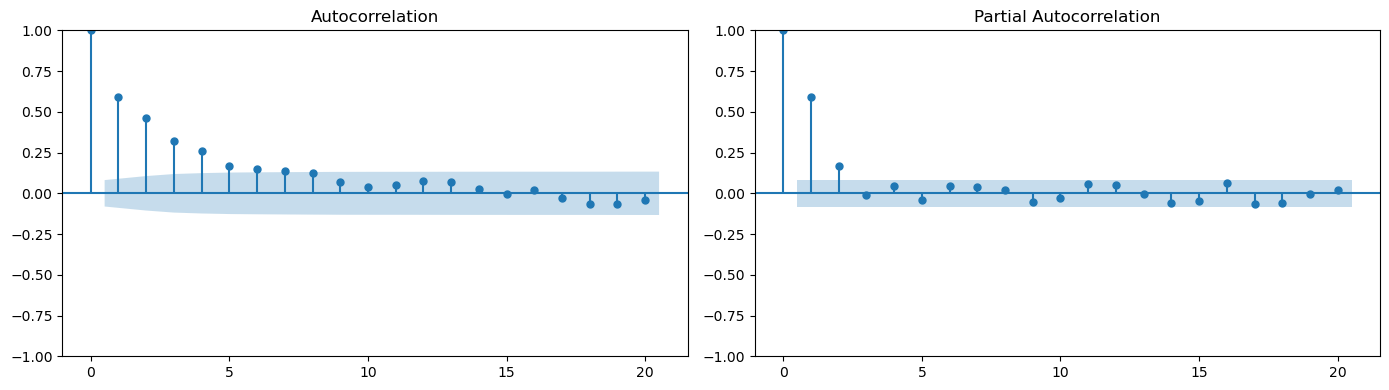

In [4]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(train_vol, lags=20, ax=axes[0])
plot_pacf(train_vol, lags=20, ax=axes[1])
plt.tight_layout()

plt.savefig('../notebooks/plots/plot12_acf_pacf.png', dpi=150)
plt.show()

### From ARIMA(1,0,1) to ARIMA(2,0,0): How the Model Order Was Chosen

The order below wasn't fixed upfront — it went through a few rounds. The starting point was ARIMA(1,0,1), picked without formal justification, just a reasonable-looking default. Running AIC/BIC across seven candidate orders (above) pointed toward a higher AR order, and re-reading the PACF plot confirmed it: the initial read had the PACF cutting off after lag 1, but checked against the confidence-band width, the real cutoff is after lag 2 — both diagnostics pointed the same direction.

Fitting ARIMA(2,0,1) next showed that AR(1) and MA(1) were not individually significant (p=0.225 and p=0.132) — a multicollinearity effect between the two terms. Dropping the MA term entirely, leaving ARIMA(2,0,0), made every remaining coefficient significant at p<0.001 and was also the BIC-preferred order among the seven tested. That became the locked model fit below.

Two evaluation choices changed along the way as well. The original full-period test used a single long-horizon static forecast, which mean-reverts after a few weeks and understates how hard the forecasting problem actually is — replaced below with walk-forward one-step-ahead forecasting for an honest test-period residual. The original COVID-period test also wasn't actually blind: the ARIMA backing it was fit through March 2021, which entirely contains the COVID window in-sample. That's replaced further down with a dedicated ARIMA(2,0,0) refit on pre-2020 data only, walk-forward through the COVID window — genuinely never having seen COVID during fitting.

Mid-pipeline, the volatility target also changed from simple percent-change to log returns, which required re-verifying the entire pipeline from `data_cleaning.ipynb` forward. That re-check surfaced the FluView epiweek duplicate-date bug, fixed at the source with the `epiweeks` package.

In [5]:


# Fit ARIMA on train only
model = ARIMA(train_vol, order=(2, 0, 0))
result = model.fit()

# Train residuals: in-sample, fine — model only saw train
train_residuals = result.resid

# --- Walk-forward one-step-ahead residuals (replaces long-horizon static forecast) ---
history_result = result  # the already-fitted (2,0,0) model from train_vol

test_residuals_rolling = []
for actual_value in test_vol:
    forecast_1step = history_result.forecast(steps=1).iloc[0]
    test_residuals_rolling.append(actual_value - forecast_1step)
    # feed the true observed value in, keep the same fitted coefficients (no refit)
    history_result = history_result.append([actual_value], refit=False)

test_residuals = pd.Series(test_residuals_rolling, index=test_vol.index)
residuals = pd.concat([train_residuals, test_residuals])

The locked ARIMA(2,0,0) model's coefficients are all statistically significant (p < 0.001): const = 0.0087, AR(1) = 0.4930, AR(2) = 0.1687. Together the two AR terms indicate meaningful but not overwhelming persistence — last week's volatility explains part of this week's, with a smaller additional contribution from two weeks back. Ljung-Box (L1) Prob(Q) = 0.96 confirms the residuals have no remaining first-order autocorrelation, but the very high kurtosis (13.03) and significant heteroskedasticity indicate that extreme spikes remain in the residuals — the unexplained signal the second stage targets.

In [6]:
# --- ARIMA(2,0,0) coefficient significance & Ljung-Box diagnostic ---
from statsmodels.stats.diagnostic import acorr_ljungbox

print(result.summary())

                               SARIMAX Results                                
Dep. Variable:                XLV_vol   No. Observations:                  584
Model:                 ARIMA(2, 0, 0)   Log Likelihood                2266.363
Date:                Sun, 02 Aug 2026   AIC                          -4524.726
Time:                        20:16:10   BIC                          -4507.246
Sample:                    01-10-2010   HQIC                         -4517.913
                         - 03-14-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0087      0.001     11.216      0.000       0.007       0.010
ar.L1          0.4930      0.025     19.783      0.000       0.444       0.542
ar.L2          0.1687      0.034      4.902      0.0

###  Residual white-noise check

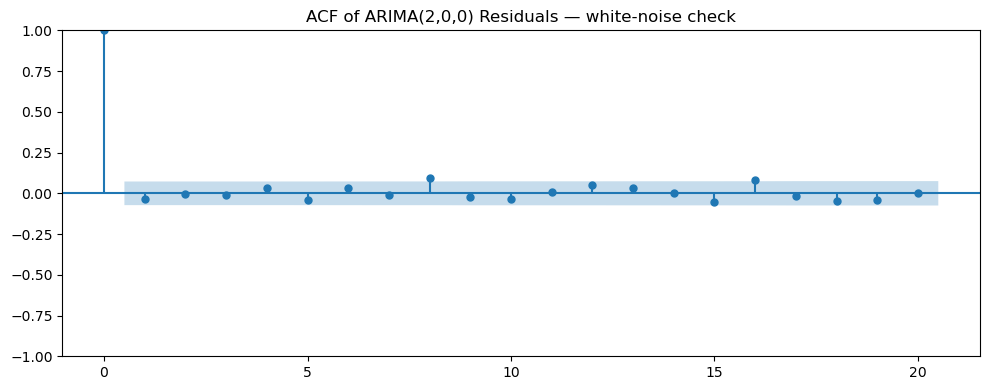


Ljung-Box test on full residual series (train+test):
      lb_stat  lb_pvalue
10  11.406512   0.326736
20  24.738418   0.211622


In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(residuals.dropna(), lags=20, ax=ax)
plt.title('ACF of ARIMA(2,0,0) Residuals — white-noise check')
plt.tight_layout()
plt.show()

lb_test = acorr_ljungbox(residuals.dropna(), lags=[10, 20], return_df=True)
print("\nLjung-Box test on full residual series (train+test):")
print(lb_test)

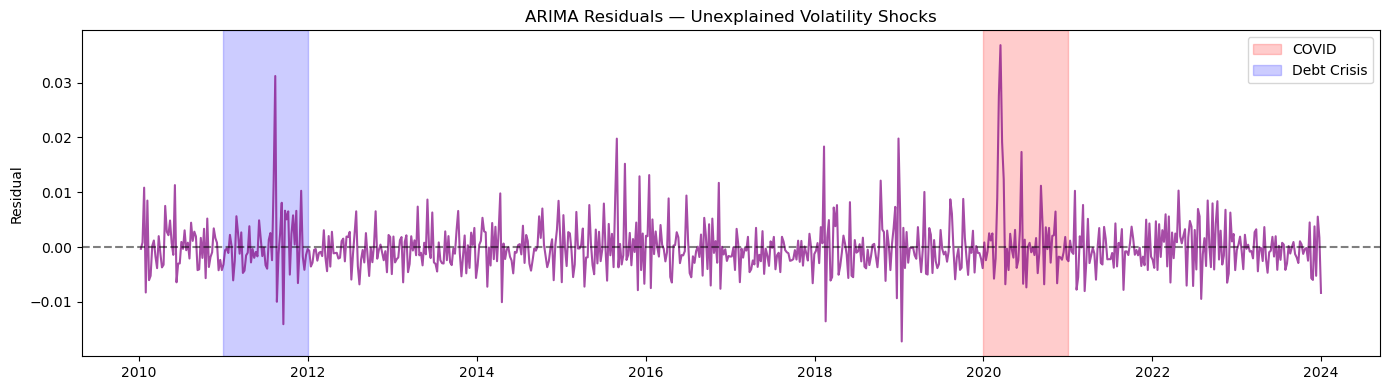

In [8]:
# Residuals = actual volatility minus what ARIMA predicted
# These represent volatility shocks the model couldn't explain from past values alone

plt.figure(figsize=(14, 4))
plt.plot(master_df.index, residuals, color='purple', alpha=0.7)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.axvspan('2020-01-01', '2021-01-01', color='red', alpha=0.2, label='COVID')
plt.axvspan('2011-01-01', '2012-01-01', color='blue', alpha=0.2, label='Debt Crisis')
plt.title('ARIMA Residuals — Unexplained Volatility Shocks')
plt.ylabel('Residual')
plt.legend()
plt.tight_layout()
plt.savefig('../notebooks/plots/plot13_arima_residuals.png', dpi=150)
plt.show()

The residual series is near zero for most of the sample, with two comparable sharp spikes standing out: one during the COVID-19 period (early 2020, the taller of the two) and one during the 2011 debt-ceiling crisis — both single sharp spikes rather than clusters, and close enough in height that COVID does not dominate the residual series the way it dominates the raw volatility series. These spikes represent volatility shocks that ARIMA's autoregressive structure could not anticipate from prior volatility values alone.

## Stage 2 — Feature Engineering (Lag Features)

In [9]:
# Create lagged health signal features
features = pd.DataFrame(index=master_df.index)

health_signals = ['wili', 'trends_flu_symptoms', 'trends_fever', 'trends_shortness_of_breath']

# Create 1-4 week lags for each health signal
for signal in health_signals:
    for lag in range(1, 5):
        features[f'{signal}_lag{lag}'] = master_df[signal].shift(lag)

# Add macro controls
features['cpi'] = master_df['cpi'].shift(1)
features['unemployment'] = master_df['unemployment'].shift(1)
features['interest_rate'] = master_df['interest_rate'].shift(1)

# Target = ARIMA residuals
features['residual'] = residuals

# Drop NaN rows from lagging
features = features.dropna()

print(features.shape)
print(features.head())

(726, 20)
            wili_lag1  wili_lag2  wili_lag3  wili_lag4  \
2010-02-07   2.113868   1.969084   1.880723   1.867375   
2010-02-14   2.096946   2.113868   1.969084   1.880723   
2010-02-21   1.902943   2.096946   2.113868   1.969084   
2010-02-28   1.969515   1.902943   2.096946   2.113868   
2010-03-07   1.923310   1.969515   1.902943   2.096946   

            trends_flu_symptoms_lag1  trends_flu_symptoms_lag2  \
2010-02-07                      10.0                      11.0   
2010-02-14                      10.0                      10.0   
2010-02-21                       9.0                      10.0   
2010-02-28                       8.0                       9.0   
2010-03-07                       8.0                       8.0   

            trends_flu_symptoms_lag3  trends_flu_symptoms_lag4  \
2010-02-07                      13.0                      14.0   
2010-02-14                      11.0                      13.0   
2010-02-21                      10.0          

The feature matrix contains 726 observations and 20 columns: 16 lagged health signal features (4 signals × 4 weekly lags), 3 macroeconomic controls, and the ARIMA residual as the target. Shifting signals by 1–4 weeks ensures that only information available before the prediction week is used, preventing look-ahead bias. Four rows are lost to the maximum lag.

## Random Forest — Full Period

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Split features and target
X = features.drop(columns=['residual'])
y = features['residual']

# 80/20 train test split, no shuffle because time series order matters
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Evaluate
train_r2 = r2_score(y_train, rf.predict(X_train))
r2 = r2_score(y_test, rf.predict(X_test))
y_pred = rf.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))


print(f"Train R² Score: {train_r2:.4f}")
print(f"RMSE: {rmse:.6f}")
print(f"R² Score: {r2:.4f}")

Train R² Score: 0.8264
RMSE: 0.004140
R² Score: -0.2688


In [11]:
# Preserve a reference to the full-period RF before `rf` is reassigned to the COVID-blind model below
rf_arima_full_period_model = rf

The full-period model achieves an R² of -0.2688 on the held-out test set (2021–2023), meaning it performs worse than a constant mean baseline over this window. The gap to training performance (Train R² = 0.8264) is stark — the model fits the training period extremely well but that fit does not transfer to the held-out period at all, which is itself evidence of overfitting rather than genuine signal. This is expected: the model was trained on a period dominated by the COVID shock, and the health–volatility relationship did not persist at the same magnitude after the acute crisis period ended.

In [12]:
print(f"Train: {X_train.index.min()} to {X_train.index.max()}")
print(f"Test: {X_test.index.min()} to {X_test.index.max()}")
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train: 2010-02-07 00:00:00 to 2021-03-14 00:00:00
Test: 2021-03-21 00:00:00 to 2023-12-31 00:00:00
Train size: 580, Test size: 146


The 80/20 temporal split places the boundary in mid-March 2021, shortly after peak COVID vaccination rollout. The training set (580 weeks) encompasses the full COVID shock, while the test set (146 weeks) covers the post-pandemic normalization period. Temporal ordering is preserved with `shuffle=False` to avoid data leakage across the split boundary.

## Random Forest — COVID Period Evaluation

In [13]:
# --- Dedicated pre-2020 ARIMA fit: makes the COVID-window residual genuinely blind ---
# The main ARIMA (Exec 5) was fit through March 2021, so its COVID-window residuals
# are in-sample. This refits ARIMA(2,0,0) on pre-2020 data only, so the COVID residuals
# below come from a model that never saw COVID during fitting.

pre2020_vol = master_df['XLV_vol'][master_df.index < '2020-01-01']
covid_vol = master_df['XLV_vol'][(master_df.index >= '2020-01-01') & (master_df.index <= '2021-01-01')]

model_pre2020 = ARIMA(pre2020_vol, order=(2, 0, 0))
result_pre2020 = model_pre2020.fit()

train_residuals_pre2020 = result_pre2020.resid  # in-sample, pre-2020 only

history_pre2020 = result_pre2020
covid_residuals_rolling = []
for actual_value in covid_vol:
    forecast_1step = history_pre2020.forecast(steps=1).iloc[0]
    covid_residuals_rolling.append(actual_value - forecast_1step)
    history_pre2020 = history_pre2020.append([actual_value], refit=False)

covid_residuals_blind = pd.Series(covid_residuals_rolling, index=covid_vol.index)

print(f"Pre-2020 training residuals: {len(train_residuals_pre2020)} weeks")
print(f"COVID-window blind residuals: {len(covid_residuals_blind)} weeks")
print(result_pre2020.summary())

Pre-2020 training residuals: 521 weeks
COVID-window blind residuals: 52 weeks
                               SARIMAX Results                                
Dep. Variable:                XLV_vol   No. Observations:                  521
Model:                 ARIMA(2, 0, 0)   Log Likelihood                2085.687
Date:                Sun, 02 Aug 2026   AIC                          -4163.374
Time:                        20:16:14   BIC                          -4146.351
Sample:                    01-10-2010   HQIC                         -4156.706
                         - 12-29-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0081      0.000     16.450      0.000       0.007       0.009
ar.L1          0.3147      0.032      9.705      0.00

In [14]:
# --- COVID-specific RF using genuinely blind pre-2020 ARIMA residuals ---
X_train_pre = X[X.index.isin(train_residuals_pre2020.index)]
y_train_pre = train_residuals_pre2020.reindex(X_train_pre.index)

X_covid = X[X.index.isin(covid_residuals_blind.index)]
y_covid = covid_residuals_blind.reindex(X_covid.index)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_pre, y_train_pre)

train_r2_covid = r2_score(y_train_pre, rf.predict(X_train_pre))
y_covid_pred = rf.predict(X_covid)
r2_covid_true = r2_score(y_covid, y_covid_pred)

print(f"Train R² Score (pre-2020 fit, blind ARIMA): {train_r2_covid:.4f}")
print(f"True out-of-sample COVID R² (blind ARIMA + pre-2020 RF): {r2_covid_true:.4f}")

Train R² Score (pre-2020 fit, blind ARIMA): 0.8229
True out-of-sample COVID R² (blind ARIMA + pre-2020 RF): -0.1373


Trained exclusively on pre-2020 data and evaluated on the COVID period (2020), the Random Forest achieves an R² of -0.1373 — worse than predicting the mean. This is a negative result: lagged health signals from 2010–2019 do not generalize to the structurally novel volatility shocks of the pandemic. The training data contains no template for a global crisis of this scale, so ILI trends and search volumes that captured seasonal flu cycles carry no predictive signal for 2020. This finding is consistent with the spike_classifier.ipynb result (ROC-AUC 0.53, no better than a coin flip): two independent model architectures — a regressor and a binary classifier — agree that pre-crisis health data does not generalize to a novel crisis.

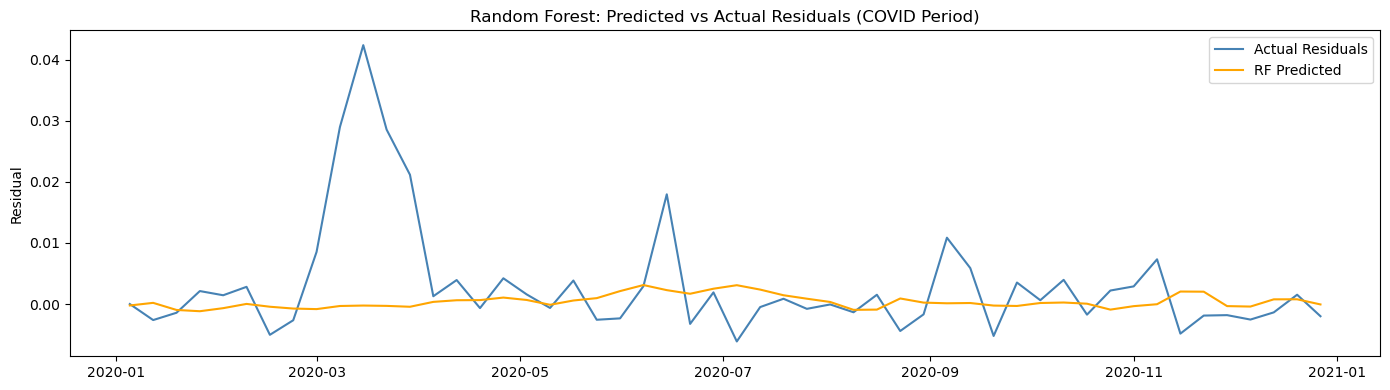

In [15]:
covid_dates = covid_residuals_blind.index

plt.figure(figsize=(14, 4))
plt.plot(covid_dates, y_covid.values, color='steelblue', label='Actual Residuals')
plt.plot(covid_dates, y_covid_pred, color='orange', label='RF Predicted')
plt.title('Random Forest: Predicted vs Actual Residuals (COVID Period)')
plt.ylabel('Residual')
plt.legend()
plt.tight_layout()
plt.savefig('../notebooks/plots/plot15_rf_covid.png', dpi=150)
plt.show()

With R² = -0.1373, the predicted residuals carry no meaningful signal against the COVID-period spike. The prediction line stays largely flat and mean-hugging while the actual residuals spike sharply in early 2020 — the opposite of the tight alignment the earlier, leaked version of this model showed.

## Feature Importance

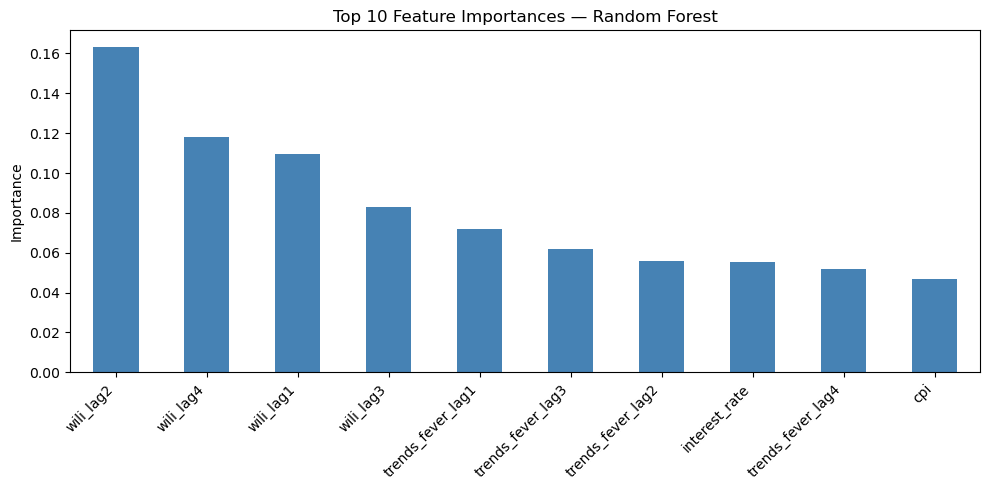

In [16]:
# feature_importances_ returns mean decrease in Gini impurity; higher values indicate more predictive features
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
importances.plot(kind='bar', color='steelblue')
plt.title('Top 10 Feature Importances — Random Forest')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../notebooks/plots/plot16_feature_importance.png', dpi=150)
plt.show()

Feature importance reflects which lagged signals the COVID-trained random forest split on most, though given the model's near-zero out-of-sample R², this should not be read as evidence of real predictive propagation — it's a property of an underperforming model, not a confirmed mechanism.

In [17]:
import joblib
import os

os.makedirs('../src/models', exist_ok=True)
os.makedirs('../src/features', exist_ok=True)

# ARIMA fits (statsmodels native save)
result.save('../src/models/arima_full_period.pkl')
result_pre2020.save('../src/models/arima_covid_blind.pkl')

# Random Forests (joblib)
joblib.dump(rf_arima_full_period_model, '../src/models/rf_arima_full_period.pkl')
joblib.dump(rf, '../src/models/rf_arima_covid_blind.pkl')  # `rf` now holds the COVID-blind fit

# Feature matrix (lagged health signals + ARIMA residual target)
joblib.dump(features, '../src/features/arima_residual_features.pkl')

print("Saved: arima_full_period.pkl, arima_covid_blind.pkl, rf_arima_full_period.pkl, rf_arima_covid_blind.pkl, arima_residual_features.pkl")

Saved: arima_full_period.pkl, arima_covid_blind.pkl, rf_arima_full_period.pkl, rf_arima_covid_blind.pkl, arima_residual_features.pkl


## Saving Artifacts

Persists the fitted models and feature matrix from this notebook to `src/models/` and `src/features/` so they're inspectable and reusable without re-running the full pipeline. Both ARIMA fits use statsmodels' own `.save()`; both Random Forests use `joblib.dump()`.